# CNN-Based Waste Image Classification for Recycling

This notebook implements a complete CNN-based image classification project for the **Garbage Classification** dataset in Kaggle.

## Project methods
1. Dataset loading and exploration
2. Image preprocessing and data augmentation
3. Train / validation / test split
4. Custom CNN model
5. MobileNetV2 transfer learning model
6. ResNet50 transfer learning model
7. Model evaluation
8. Confusion matrices
9. Accuracy/loss curves
10. Grad-CAM explainability
11. Optional SHAP explainability
12. Final model comparison table

All figures are saved as **PDF** files and all tables are saved as **CSV** files.

In [3]:
# ============================================================
# 1. Import Libraries and Basic Settings
# ============================================================

import os
import time
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

2026-05-31 08:05:19.699323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780214719.888318      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780214719.946617      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780214720.404913      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780214720.404954      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780214720.404957      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
# ============================================================
# 2. Define Paths and Output Folders
# ============================================================

# Kaggle dataset path
BASE_PATH = Path("/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification")

# Output folders
OUTPUT_PATH = Path("/kaggle/working/outputs")
FIGURE_PATH = OUTPUT_PATH / "figures"
TABLE_PATH = OUTPUT_PATH / "tables"
MODEL_PATH = OUTPUT_PATH / "models"

for path in [FIGURE_PATH, TABLE_PATH, MODEL_PATH]:
    path.mkdir(parents=True, exist_ok=True)

print("Dataset path exists:", BASE_PATH.exists())
print("Output folder:", OUTPUT_PATH)
print("Figure folder:", FIGURE_PATH)
print("Table folder:", TABLE_PATH)
print("Model folder:", MODEL_PATH)

Dataset path exists: True
Output folder: /kaggle/working/outputs
Figure folder: /kaggle/working/outputs/figures
Table folder: /kaggle/working/outputs/tables
Model folder: /kaggle/working/outputs/models


In [5]:
# ============================================================
# 3. Project Configuration
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_CUSTOM_CNN = 20
EPOCHS_MOBILENETV2 = 15
EPOCHS_RESNET50 = 15
AUTOTUNE = tf.data.AUTOTUNE

# Optional: set this to an integer such as 600 if you want a faster test run.
# Keep it as None for the full final project run.
MAX_IMAGES_PER_CLASS = None

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Max images per class:", MAX_IMAGES_PER_CLASS)

Image size: (224, 224)
Batch size: 32
Max images per class: None


In [6]:
# ============================================================
# 4. Load Dataset into a DataFrame
# ============================================================

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

image_paths = []
labels = []

for class_folder in BASE_PATH.iterdir():
    if class_folder.is_dir():
        files = [
            file for file in class_folder.iterdir()
            if file.suffix.lower() in image_extensions
        ]

        # Optional subsampling for faster experiments
        if MAX_IMAGES_PER_CLASS is not None:
            files = files[:MAX_IMAGES_PER_CLASS]

        for image_file in files:
            image_paths.append(str(image_file))
            labels.append(class_folder.name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

class_names = sorted(df["label"].unique())
num_classes = len(class_names)

print("Total images:", len(df))
print("Number of classes:", num_classes)
print("Class names:", class_names)

df.head()

Total images: 15515
Number of classes: 12
Class names: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


,image_path,label
0,/kaggle/input/datasets/mostafaabla/garbage-cla...,metal
1,/kaggle/input/datasets/mostafaabla/garbage-cla...,metal
2,/kaggle/input/datasets/mostafaabla/garbage-cla...,metal
3,/kaggle/input/datasets/mostafaabla/garbage-cla...,metal
4,/kaggle/input/datasets/mostafaabla/garbage-cla...,metal


In [7]:
# ============================================================
# 5. Dataset Summary and Class Distribution
# ============================================================

class_distribution = df["label"].value_counts().reset_index()
class_distribution.columns = ["Class", "Number of Images"]
class_distribution = class_distribution.sort_values("Number of Images", ascending=False)

dataset_summary = pd.DataFrame([{
    "Dataset Name": "Garbage Classification",
    "Dataset Path": str(BASE_PATH),
    "Total Images": len(df),
    "Number of Classes": num_classes,
    "Image Type": "RGB color images",
    "Target Image Size": f"{IMG_SIZE[0]}x{IMG_SIZE[1]}",
    "Task": "Multi-class image classification"
}])

dataset_summary.to_csv(TABLE_PATH / "dataset_summary.csv", index=False)
class_distribution.to_csv(TABLE_PATH / "class_distribution.csv", index=False)

display(dataset_summary)
display(class_distribution)

,Dataset Name,Dataset Path,Total Images,Number of Classes,Image Type,Target Image Size,Task
0,Garbage Classification,/kaggle/input/datasets/mostafaabla/garbage-cla...,15515,12,RGB color images,224x224,Multi-class image classification


,Class,Number of Images
0,clothes,5325
1,shoes,1977
2,paper,1050
3,biological,985
4,battery,945
5,cardboard,891
6,plastic,865
7,white-glass,775
8,metal,769
9,trash,697


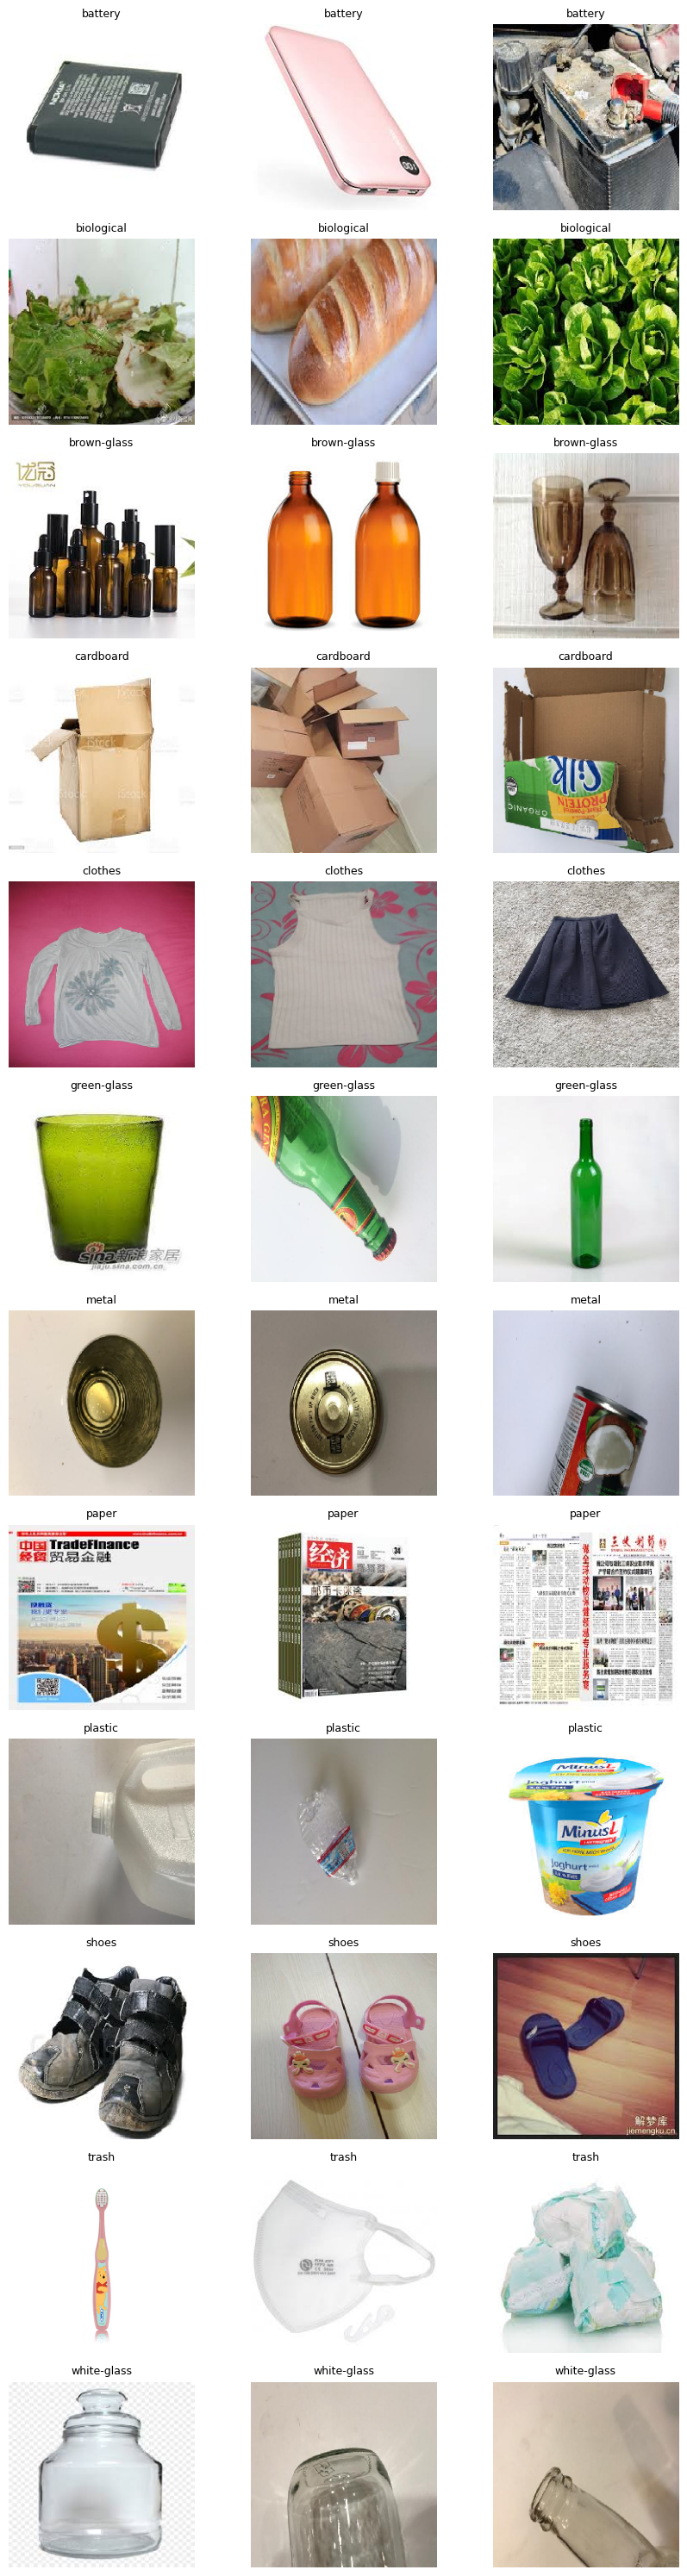

Dataset sample figure saved.


In [8]:
# ============================================================
# 6. Save Dataset Sample Figure as PDF
# ============================================================

def save_dataset_samples(df, class_names, output_file, samples_per_class=3):
    plt.figure(figsize=(samples_per_class * 3, len(class_names) * 2.5))

    plot_index = 1
    for class_name in class_names:
        sample_paths = df[df["label"] == class_name]["image_path"].sample(
            n=min(samples_per_class, len(df[df["label"] == class_name])),
            random_state=SEED
        ).values

        for image_path in sample_paths:
            img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
            plt.subplot(len(class_names), samples_per_class, plot_index)
            plt.imshow(img)
            plt.title(class_name, fontsize=9)
            plt.axis("off")
            plot_index += 1

    plt.tight_layout()
    plt.savefig(output_file, format="pdf", bbox_inches="tight")
    plt.show()

save_dataset_samples(
    df=df,
    class_names=class_names,
    output_file=FIGURE_PATH / "figure_01_dataset_samples.pdf",
    samples_per_class=3
)

print("Dataset sample figure saved.")

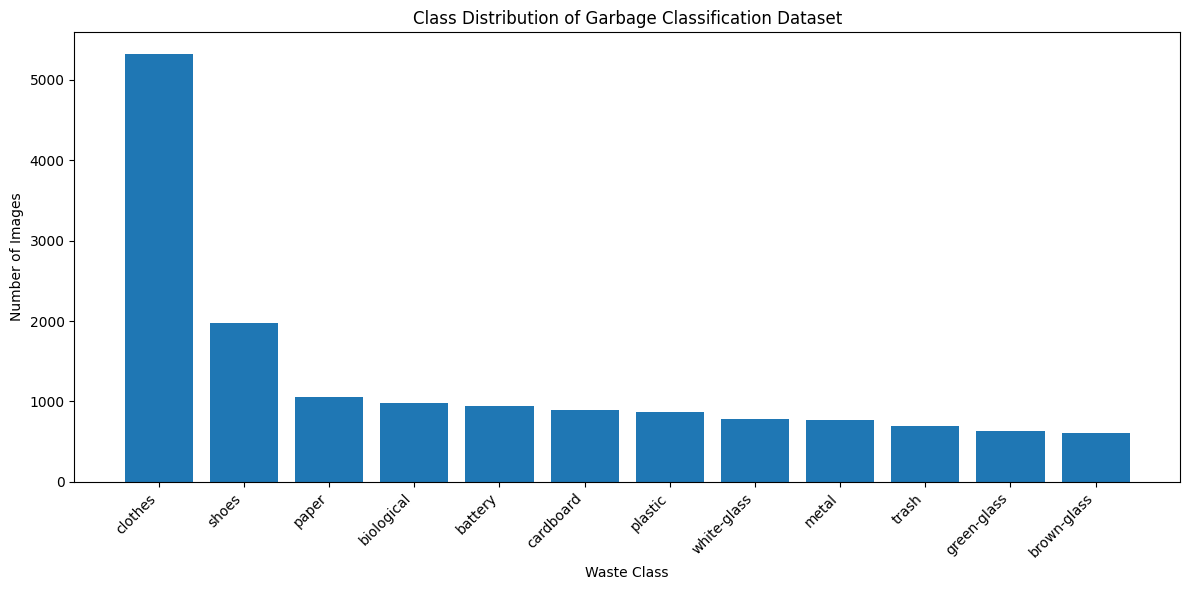

Class distribution figure saved.


In [9]:
# ============================================================
# 7. Save Class Distribution Figure as PDF
# ============================================================

plt.figure(figsize=(12, 6))
plt.bar(class_distribution["Class"], class_distribution["Number of Images"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Garbage Classification Dataset")
plt.tight_layout()
plt.savefig(FIGURE_PATH / "figure_02_class_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("Class distribution figure saved.")

In [13]:
# ============================================================
# 8. Train / Validation / Test Split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

train_df.to_csv(TABLE_PATH / "train_split.csv", index=False)
val_df.to_csv(TABLE_PATH / "validation_split.csv", index=False)
test_df.to_csv(TABLE_PATH / "test_split.csv", index=False)

split_summary = pd.DataFrame([
    {"Split": "Train", "Number of Images": len(train_df), "Percentage": len(train_df) / len(df)},
    {"Split": "Validation", "Number of Images": len(val_df), "Percentage": len(val_df) / len(df)},
    {"Split": "Test", "Number of Images": len(test_df), "Percentage": len(test_df) / len(df)}
])
split_summary.to_csv(TABLE_PATH / "split_summary.csv", index=False)
split_summary

Training images: 10860
Validation images: 2327
Testing images: 2328


,Split,Number of Images,Percentage
0,Train,10860,0.699968
1,Validation,2327,0.149984
2,Test,2328,0.150048


In [14]:
# ============================================================
# 9. Image Preprocessing Pipeline
# ============================================================

class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

pd.DataFrame(
    [{"Class": k, "Index": v} for k, v in class_to_index.items()]
).to_csv(TABLE_PATH / "class_index_mapping.csv", index=False)

def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].map(class_to_index).values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED)

    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_dataset = create_dataset(train_df, shuffle=True)
val_dataset = create_dataset(val_df, shuffle=False)
test_dataset = create_dataset(test_df, shuffle=False)

for images, labels_batch in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels_batch.shape)
    print("First labels:", labels_batch[:10].numpy())

I0000 00:00:1780214824.379125      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780214824.385041      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
First labels: [9 5 9 0 6 4 0 0 6 9]


In [15]:
# ============================================================
# 10. Data Augmentation
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


In [16]:
# ============================================================
# 11. Utility Functions for Training, Evaluation, and Saving Results
# ============================================================

all_model_results = []

def save_training_curves(history, model_name):
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(TABLE_PATH / f"{model_name}_training_history.csv", index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["accuracy"], label="Training Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f"{model_name}_accuracy_curve.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["loss"], label="Training Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f"{model_name}_loss_curve.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    return history_df

def get_predictions(model, dataset):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels_batch in dataset:
        probabilities = model.predict(images, verbose=0)
        predictions = np.argmax(probabilities, axis=1)

        y_true.extend(labels_batch.numpy())
        y_pred.extend(predictions)
        y_prob.extend(probabilities)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

def evaluate_and_save_model(model, dataset, model_name, training_time):
    y_true, y_pred, y_prob = get_predictions(model, dataset)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(TABLE_PATH / f"{model_name}_classification_report.csv")

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=True)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f"{model_name}_confusion_matrix.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    result = {
        "Model": model_name,
        "Test Accuracy": accuracy,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1-score": f1,
        "Training Time (seconds)": training_time,
        "Parameters": model.count_params()
    }

    pd.DataFrame([result]).to_csv(TABLE_PATH / f"{model_name}_results.csv", index=False)

    # Save misclassified examples table
    test_paths = test_df["image_path"].values
    test_labels_text = test_df["label"].values

    # This assumes test_dataset was created from test_df without shuffle.
    misclassified_rows = []
    for idx, (true_idx, pred_idx) in enumerate(zip(y_true, y_pred)):
        if true_idx != pred_idx:
            misclassified_rows.append({
                "image_path": test_paths[idx] if idx < len(test_paths) else "",
                "true_label": class_names[true_idx],
                "predicted_label": class_names[pred_idx],
                "predicted_probability": float(np.max(y_prob[idx]))
            })

    misclassified_df = pd.DataFrame(misclassified_rows)
    misclassified_df.to_csv(TABLE_PATH / f"{model_name}_misclassified_examples.csv", index=False)

    print(f"{model_name} Test Results")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Parameters: {model.count_params()}")

    all_model_results.append(result)

    return result, report_df, cm, y_true, y_pred, y_prob

def save_model_architecture_table(model, model_name):
    rows = []
    for layer in model.layers:
        rows.append({
            "Model": model_name,
            "Layer Name": layer.name,
            "Layer Type": layer.__class__.__name__,
            "Output Shape": str(getattr(layer, "output_shape", "N/A")),
            "Parameters": layer.count_params()
        })

    architecture_df = pd.DataFrame(rows)
    architecture_df.to_csv(TABLE_PATH / f"{model_name}_architecture.csv", index=False)
    return architecture_df

In [17]:
# ============================================================
# 12. Model 1: Custom CNN
# ============================================================

custom_cnn = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
], name="custom_cnn")

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()
save_model_architecture_table(custom_cnn, "custom_cnn")

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,308 (434.80 KB)

 Trainable params: 111,308 (434.80 KB)

 Non-trainable params: 0 (0.00 B)

,Model,Layer Name,Layer Type,Output Shape,Parameters
0,custom_cnn,data_augmentation,Sequential,"(None, 224, 224, 3)",0
1,custom_cnn,conv2d,Conv2D,N/A,896
2,custom_cnn,max_pooling2d,MaxPooling2D,N/A,0
3,custom_cnn,conv2d_1,Conv2D,N/A,18496
4,custom_cnn,max_pooling2d_1,MaxPooling2D,N/A,0
5,custom_cnn,conv2d_2,Conv2D,N/A,73856
6,custom_cnn,max_pooling2d_2,MaxPooling2D,N/A,0
7,custom_cnn,global_average_pooling2d,GlobalAveragePooling2D,N/A,0
8,custom_cnn,dense,Dense,N/A,16512
9,custom_cnn,dropout,Dropout,N/A,0


In [18]:
# ============================================================
# 13. Train Custom CNN
# ============================================================

custom_cnn_model_path = MODEL_PATH / "custom_cnn_best.keras"

custom_cnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(custom_cnn_model_path),
        monitor="val_loss",
        save_best_only=True
    )
]

start_time = time.time()

custom_cnn_history = custom_cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_CUSTOM_CNN,
    callbacks=custom_cnn_callbacks
)

custom_cnn_training_time = time.time() - start_time

print("Custom CNN training completed.")
print(f"Training time: {custom_cnn_training_time:.2f} seconds")

Epoch 1/20


I0000 00:00:1780214854.215654     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


340/340 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step - accuracy: 0.3678 - loss: 2.0269 - val_accuracy: 0.4908 - val_loss: 1.5661
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.5060 - loss: 1.4986 - val_accuracy: 0.5277 - val_loss: 1.4885
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.5395 - loss: 1.3940 - val_accuracy: 0.5664 - val_loss: 1.3279
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.5639 - loss: 1.3241 - val_accuracy: 0.5909 - val_loss: 1.2555
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.5761 - loss: 1.2766 - val_accuracy: 0.6072 - val_loss: 1.1905
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.5888 - loss: 1.2211 - val_accuracy: 0.6218 - val_loss: 1.1530
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.5942 - loss: 1.1977 - val_accuracy: 0.6150 - val_loss: 1.1428
Epoch 8/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.6077 - loss: 1.1746 - val_accurac

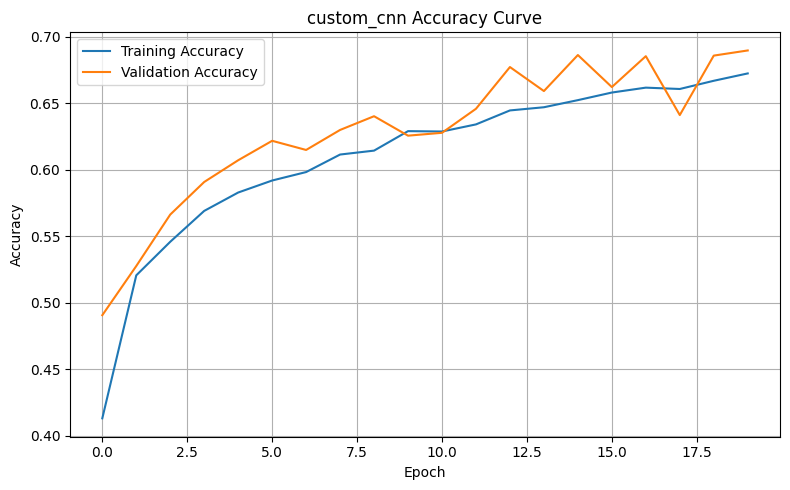

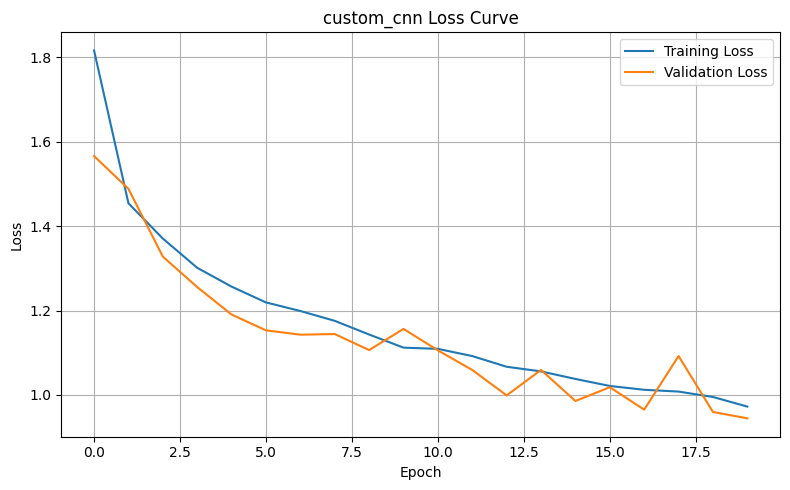

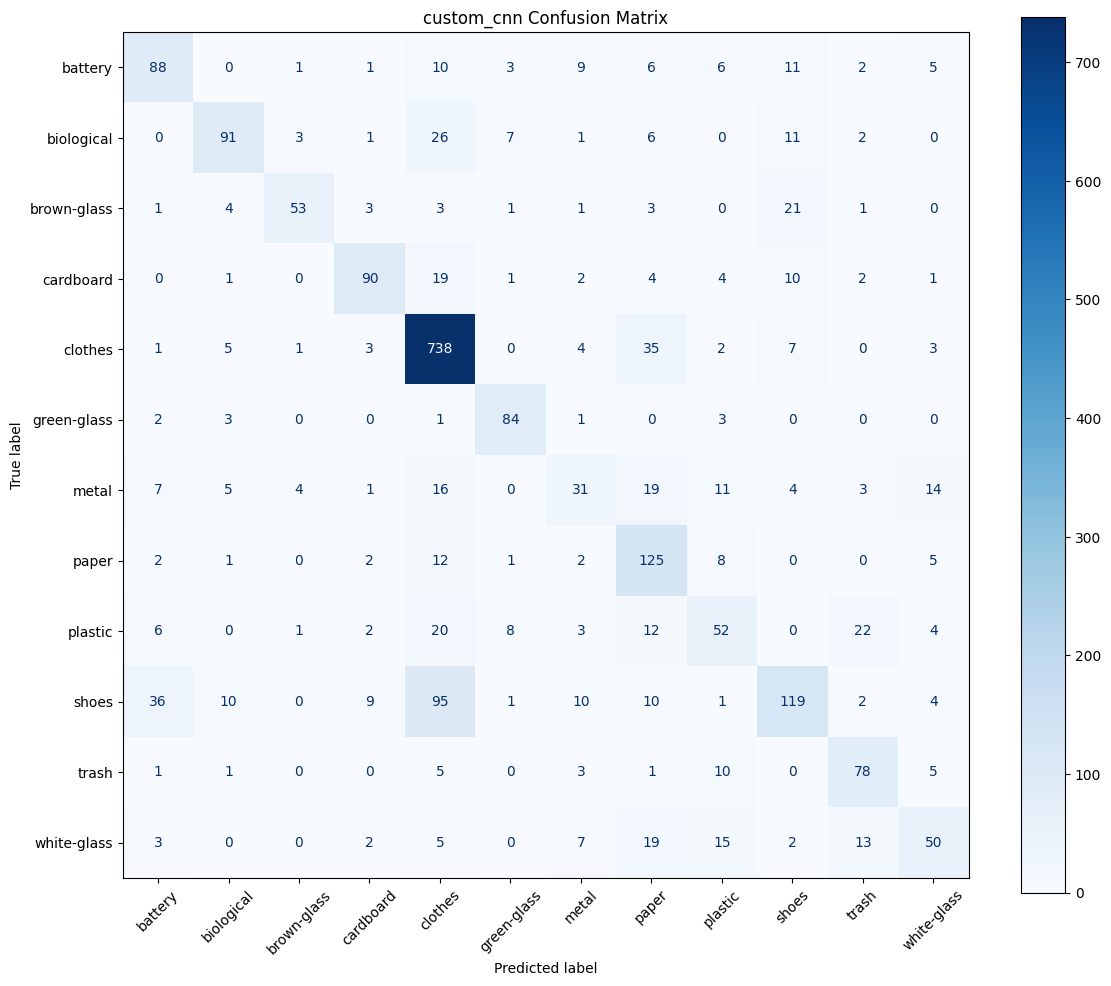

custom_cnn Test Results
Accuracy:  0.6869
Precision: 0.6806
Recall:    0.6869
F1-score:  0.6727
Training time: 383.21 seconds
Parameters: 111308


In [19]:
# ============================================================
# 14. Custom CNN Curves and Evaluation
# ============================================================

custom_cnn_history_df = save_training_curves(custom_cnn_history, "custom_cnn")

custom_cnn_result, custom_cnn_report_df, custom_cnn_cm, custom_cnn_y_true, custom_cnn_y_pred, custom_cnn_y_prob = evaluate_and_save_model(
    model=custom_cnn,
    dataset=test_dataset,
    model_name="custom_cnn",
    training_time=custom_cnn_training_time
)

In [20]:
# ============================================================
# 15. Model 2: MobileNetV2 Transfer Learning
# ============================================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenetv2_preprocess

def build_mobilenetv2_model():
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = layers.Lambda(lambda img: mobilenetv2_preprocess(img * 255.0), name="mobilenetv2_preprocess")(x)

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer_learning")
    return model

mobilenetv2_model = build_mobilenetv2_model()

mobilenetv2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenetv2_model.summary()
save_model_architecture_table(mobilenetv2_model, "mobilenetv2")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │        15,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,356 (8.67 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

,Model,Layer Name,Layer Type,Output Shape,Parameters
0,mobilenetv2,input_layer_2,InputLayer,N/A,0
1,mobilenetv2,data_augmentation,Sequential,"(None, 224, 224, 3)",0
2,mobilenetv2,mobilenetv2_preprocess,Lambda,N/A,0
3,mobilenetv2,mobilenetv2_1.00_224,Functional,"(None, 7, 7, 1280)",2257984
4,mobilenetv2,global_average_pooling2d_1,GlobalAveragePooling2D,N/A,0
5,mobilenetv2,dropout_1,Dropout,N/A,0
6,mobilenetv2,dense_2,Dense,N/A,15372


In [21]:
# ============================================================
# 16. Train MobileNetV2
# ============================================================

mobilenetv2_model_path = MODEL_PATH / "mobilenetv2_best.keras"

mobilenetv2_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(mobilenetv2_model_path),
        monitor="val_loss",
        save_best_only=True
    )
]

start_time = time.time()

mobilenetv2_history = mobilenetv2_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_MOBILENETV2,
    callbacks=mobilenetv2_callbacks
)

mobilenetv2_training_time = time.time() - start_time

print("MobileNetV2 training completed.")
print(f"Training time: {mobilenetv2_training_time:.2f} seconds")

Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 31s 75ms/step - accuracy: 0.5965 - loss: 1.3419 - val_accuracy: 0.9020 - val_loss: 0.3527
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.8858 - loss: 0.3924 - val_accuracy: 0.9209 - val_loss: 0.2633
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9053 - loss: 0.3101 - val_accuracy: 0.9295 - val_loss: 0.2356
Epoch 4/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9154 - loss: 0.2702 - val_accuracy: 0.9330 - val_loss: 0.2174
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.9228 - loss: 0.2542 - val_accuracy: 0.9347 - val_loss: 0.2021
Epoch 6/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.9290 - loss: 0.2259 - val_accuracy: 0.9355 - val_loss: 0.1928
Epoch 7/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - accuracy: 0.9329 - loss: 0.2170 - val_accuracy: 0.9377 - val_loss: 0.1982
Epoch 8/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.9387 - loss: 0.1969 - 

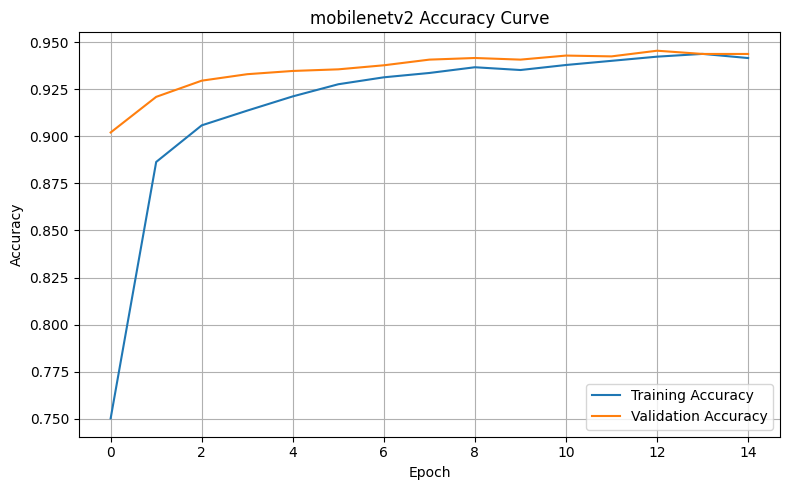

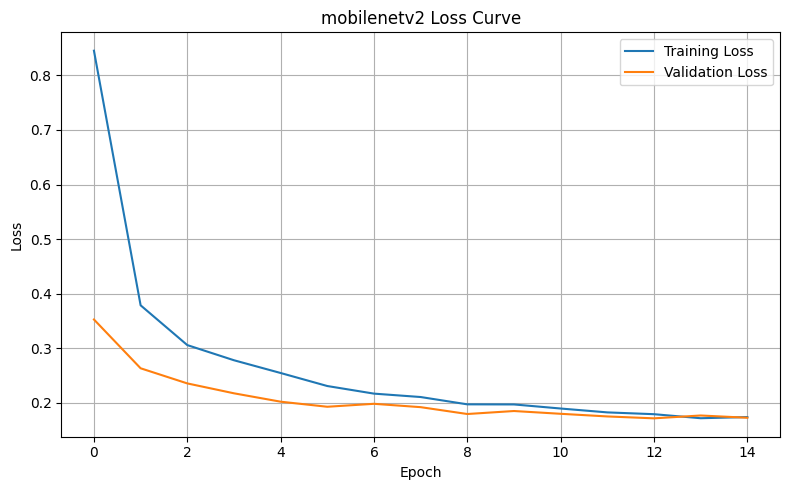

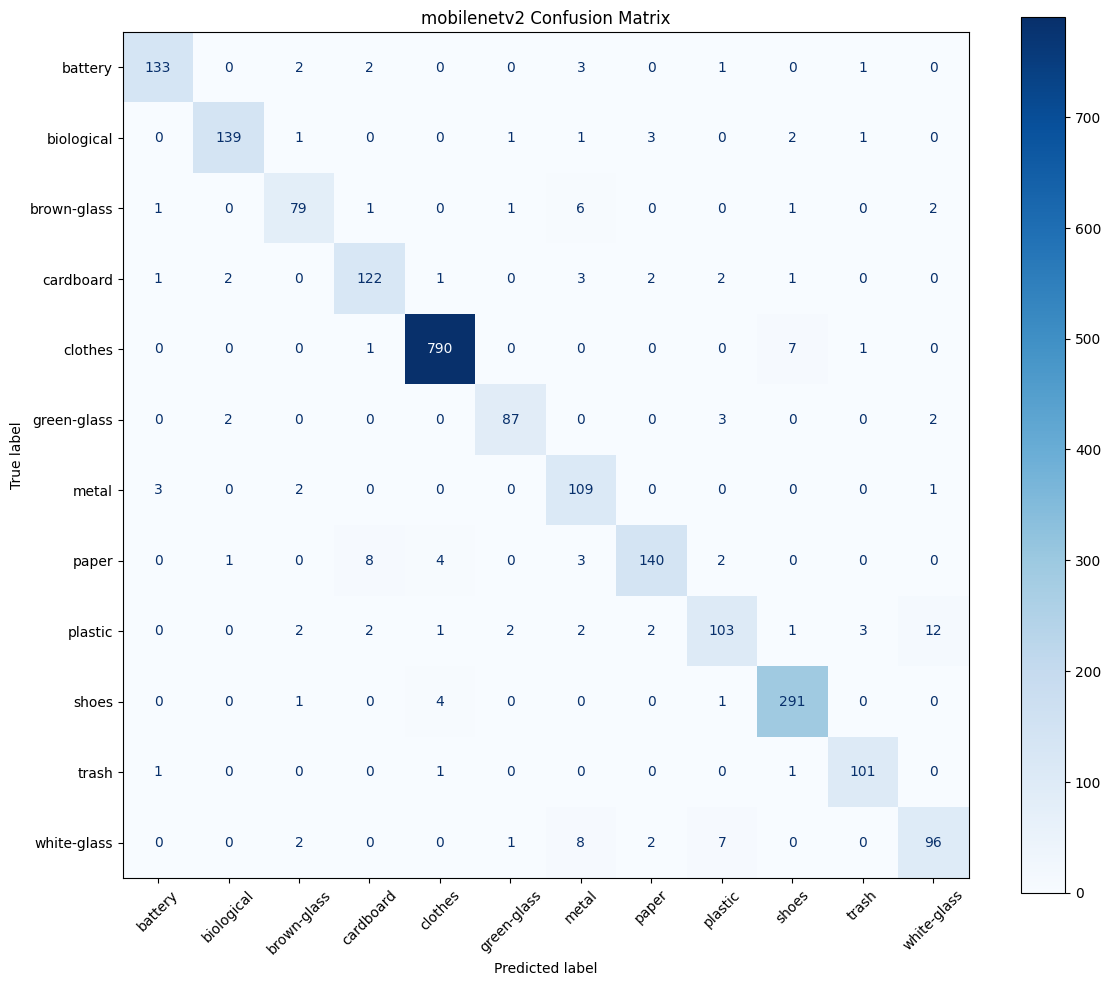

mobilenetv2 Test Results
Accuracy:  0.9407
Precision: 0.9414
Recall:    0.9407
F1-score:  0.9406
Training time: 352.85 seconds
Parameters: 2273356


In [23]:
# ============================================================
# 17. MobileNetV2 Curves and Evaluation
# ============================================================

mobilenetv2_history_df = save_training_curves(mobilenetv2_history, "mobilenetv2")

mobilenetv2_result, mobilenetv2_report_df, mobilenetv2_cm, mobilenetv2_y_true, mobilenetv2_y_pred, mobilenetv2_y_prob = evaluate_and_save_model(
    model=mobilenetv2_model,
    dataset=test_dataset,
    model_name="mobilenetv2",
    training_time=mobilenetv2_training_time
)

In [25]:
# ============================================================
# 18. Model 3: ResNet50 Transfer Learning
# ============================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess

def build_resnet50_model():
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = layers.Lambda(lambda img: resnet50_preprocess(img * 255.0), name="resnet50_preprocess")(x)

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="resnet50_transfer_learning")
    return model

resnet50_model = build_resnet50_model()

resnet50_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet50_model.summary()
save_model_architecture_table(resnet50_model, "resnet50")

Model: "resnet50_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocess (Lambda)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │        24,588 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,612,300 (90.07 MB)

 Trainable params: 24,588 (96.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

,Model,Layer Name,Layer Type,Output Shape,Parameters
0,resnet50,input_layer_6,InputLayer,N/A,0
1,resnet50,data_augmentation,Sequential,"(None, 224, 224, 3)",0
2,resnet50,resnet50_preprocess,Lambda,N/A,0
3,resnet50,resnet50,Functional,"(None, 7, 7, 2048)",23587712
4,resnet50,global_average_pooling2d_3,GlobalAveragePooling2D,N/A,0
5,resnet50,dropout_3,Dropout,N/A,0
6,resnet50,dense_4,Dense,N/A,24588


In [26]:
# ============================================================
# 19. Train ResNet50
# ============================================================

resnet50_model_path = MODEL_PATH / "resnet50_best.keras"

resnet50_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(resnet50_model_path),
        monitor="val_loss",
        save_best_only=True
    )
]

start_time = time.time()

resnet50_history = resnet50_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_RESNET50,
    callbacks=resnet50_callbacks
)

resnet50_training_time = time.time() - start_time

print("ResNet50 training completed.")
print(f"Training time: {resnet50_training_time:.2f} seconds")

Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 69s 178ms/step - accuracy: 0.6824 - loss: 1.0379 - val_accuracy: 0.9248 - val_loss: 0.2339
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 56s 165ms/step - accuracy: 0.9149 - loss: 0.2677 - val_accuracy: 0.9385 - val_loss: 0.1902
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 56s 164ms/step - accuracy: 0.9337 - loss: 0.2103 - val_accuracy: 0.9407 - val_loss: 0.1775
Epoch 4/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 56s 164ms/step - accuracy: 0.9383 - loss: 0.1822 - val_accuracy: 0.9446 - val_loss: 0.1608
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 55s 163ms/step - accuracy: 0.9467 - loss: 0.1557 - val_accuracy: 0.9476 - val_loss: 0.1602
Epoch 6/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.9543 - loss: 0.1393 - val_accuracy: 0.9403 - val_loss: 0.1847
Epoch 7/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 55s 162ms/step - accuracy: 0.9573 - loss: 0.1279 - val_accuracy: 0.9420 - val_loss: 0.1623
Epoch 8/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 55s 162ms/step - accuracy: 0.9584 - loss: 0

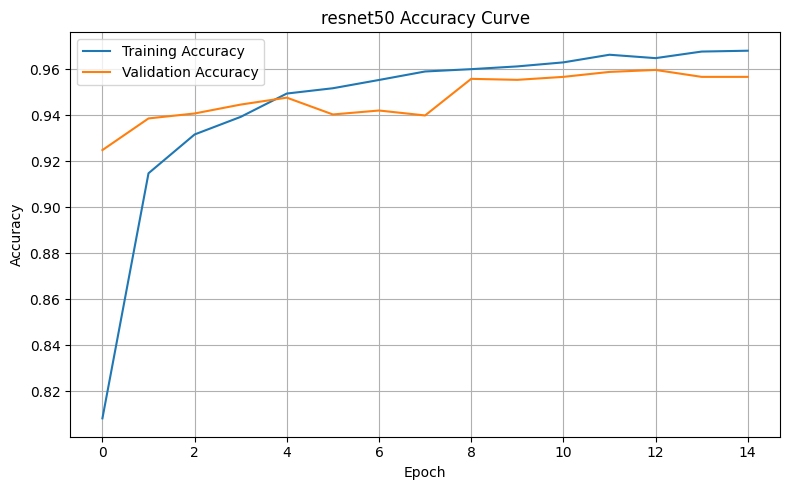

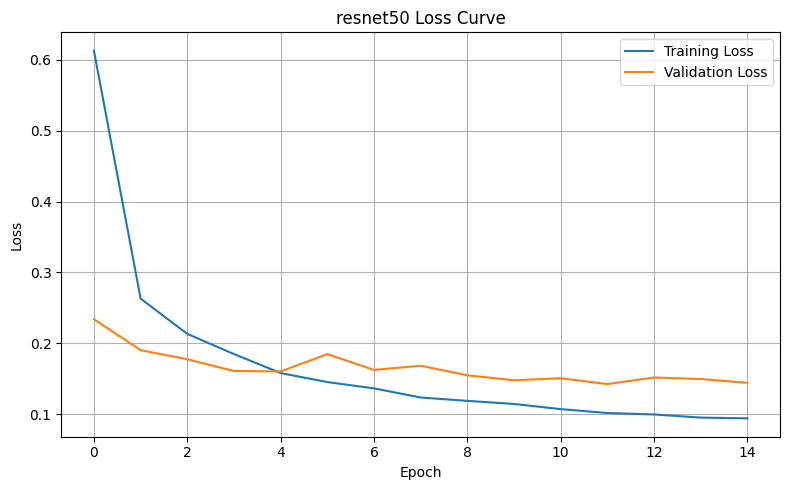

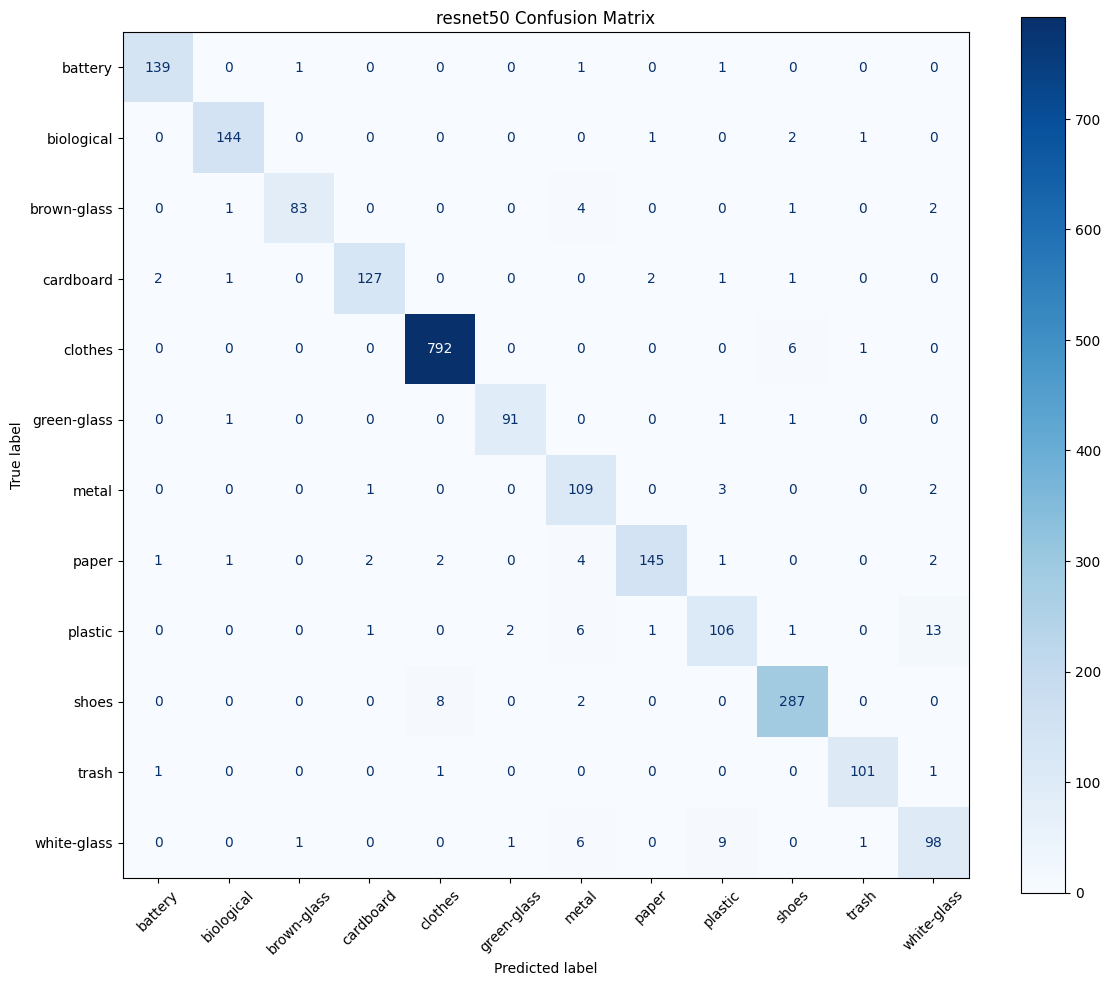

resnet50 Test Results
Accuracy:  0.9545
Precision: 0.9553
Recall:    0.9545
F1-score:  0.9545
Training time: 844.04 seconds
Parameters: 23612300


In [27]:
# ============================================================
# 20. ResNet50 Curves and Evaluation
# ============================================================

resnet50_history_df = save_training_curves(resnet50_history, "resnet50")

resnet50_result, resnet50_report_df, resnet50_cm, resnet50_y_true, resnet50_y_pred, resnet50_y_prob = evaluate_and_save_model(
    model=resnet50_model,
    dataset=test_dataset,
    model_name="resnet50",
    training_time=resnet50_training_time
)

In [130]:
# ============================================================
# 21. Final Model Comparison Table
# ============================================================

model_comparison_df = pd.DataFrame(all_model_results)

model_comparison_df.to_csv(TABLE_PATH / "final_model_comparison_table.csv", index=False)

model_comparison_df

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-score,Training Time (seconds),Parameters
0,custom_cnn,0.686856,0.680561,0.686856,0.672735,383.213568,111308
1,mobilenetv2,0.940722,0.941356,0.940722,0.940555,352.848676,2273356
2,mobilenetv2,0.940722,0.941356,0.940722,0.940555,352.848676,2273356
3,resnet50,0.954467,0.955301,0.954467,0.954517,844.041589,23612300


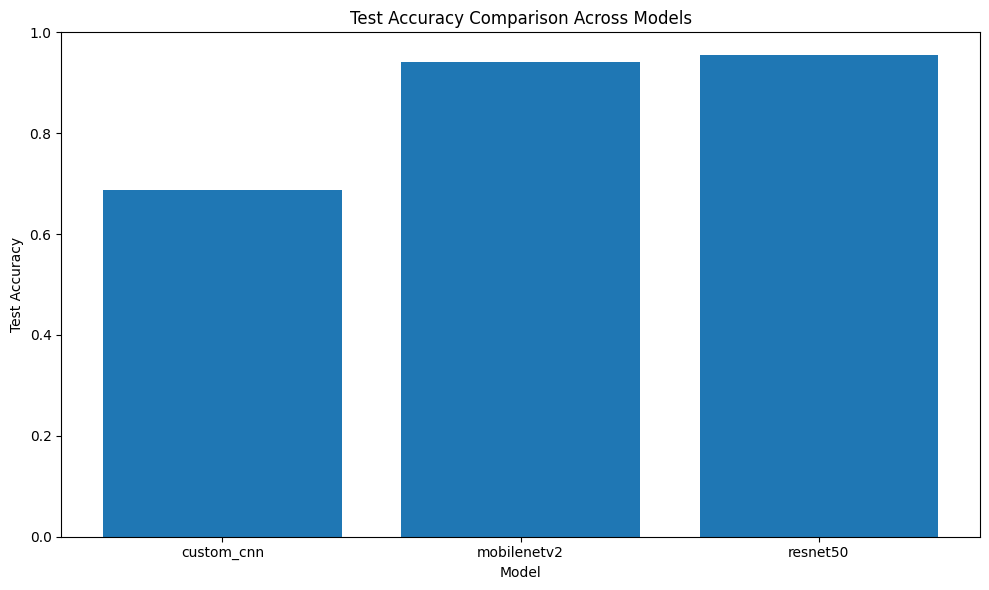

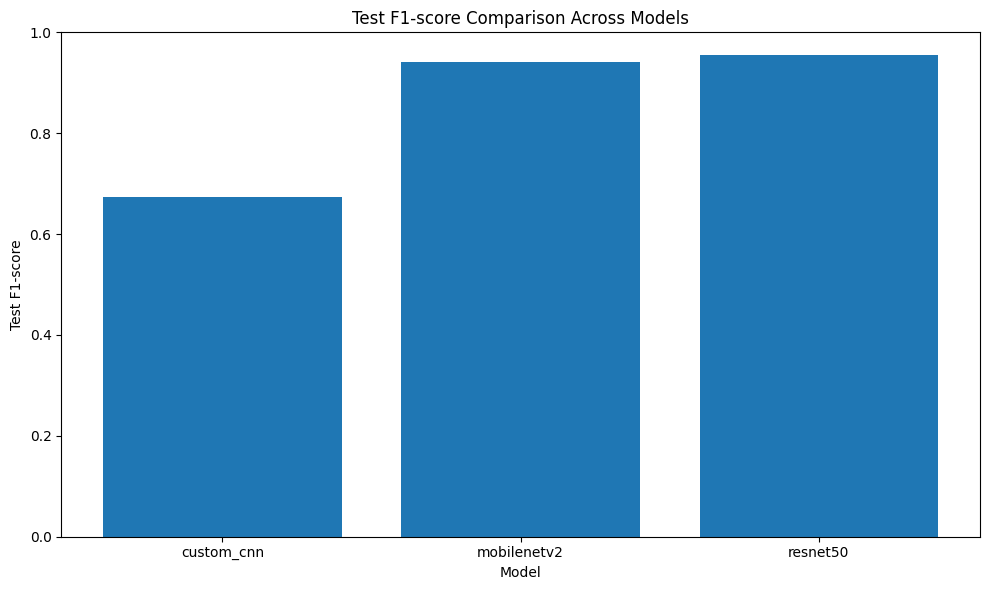

In [29]:
# ============================================================
# 22. Model Comparison Figure as PDF
# ============================================================

plt.figure(figsize=(10, 6))
plt.bar(model_comparison_df["Model"], model_comparison_df["Test Accuracy"])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison Across Models")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURE_PATH / "figure_model_accuracy_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(model_comparison_df["Model"], model_comparison_df["Test F1-score"])
plt.xlabel("Model")
plt.ylabel("Test F1-score")
plt.title("Test F1-score Comparison Across Models")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURE_PATH / "figure_model_f1_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [98]:
# ============================================================
# 23. Grad-CAM Utility Functions
# ============================================================

def find_last_conv_layer_name(model):
    # Search from the end of the model for a Conv2D layer.
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
        if isinstance(layer, keras.Model):
            nested_name = find_last_conv_layer_name(layer)
            if nested_name is not None:
                return nested_name
    return None

def get_nested_layer(model, layer_name):
    for layer in model.layers:
        if layer.name == layer_name:
            return layer
        if isinstance(layer, keras.Model):
            try:
                return layer.get_layer(layer_name)
            except ValueError:
                pass
    raise ValueError(f"Layer {layer_name} not found.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    is_nested = False
    sub_model = None
    
    try:
        model.get_layer(last_conv_layer_name)
    except ValueError:
        for layer in model.layers:
            if hasattr(layer, 'layers'):
                try:
                    layer.get_layer(last_conv_layer_name)
                    sub_model = layer
                    is_nested = True
                    break
                except ValueError:
                    continue

    if not is_nested:
        last_conv_layer = model.get_layer(last_conv_layer_name)
        last_conv_layer_model = tf.keras.Model(model.inputs, last_conv_layer.output)

        classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
        x = classifier_input
        layer_names = [layer.name for layer in model.layers]
        start_idx = layer_names.index(last_conv_layer_name) + 1
        for layer in model.layers[start_idx:]:
            x = layer(x)
        classifier_model = tf.keras.Model(classifier_input, x)

        with tf.GradientTape() as tape:
            last_conv_layer_output = last_conv_layer_model(img_tensor)
            tape.watch(last_conv_layer_output)
            predictions = classifier_model(last_conv_layer_output)
            
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, last_conv_layer_output)
        conv_outputs = last_conv_layer_output.numpy()[0]
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()

    else:
        inner_conv_layer = sub_model.get_layer(last_conv_layer_name)
        sub_grad_model = tf.keras.Model(inputs=sub_model.inputs, outputs=[inner_conv_layer.output, sub_model.output])
        
        with tf.GradientTape() as tape:

            conv_outputs, sub_predicted = sub_grad_model(img_tensor)
            tape.watch(conv_outputs)

            x = sub_predicted
            sub_model_idx = model.layers.index(sub_model)
            for layer in model.layers[sub_model_idx + 1:]:
                x = layer(x)
            predictions = x
            
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, conv_outputs)
        conv_outputs = conv_outputs.numpy()[0]
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]
        
    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap

def overlay_heatmap_on_image(image, heatmap, alpha=0.4):
    heatmap = tf.image.resize(heatmap[..., np.newaxis], (image.shape[0], image.shape[1])).numpy().squeeze()
    heatmap = np.uint8(255 * heatmap)
    colormap = plt.cm.jet(heatmap)[:, :, :3]
    overlayed = (colormap * alpha + image * (1 - alpha))
    overlayed = np.clip(overlayed, 0, 1)
    return overlayed

def collect_prediction_examples(model, dataset, max_correct=2, max_incorrect=2):
    correct = []
    incorrect = []

    for images, labels_batch in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        for i in range(images.shape[0]):
            example = {
                "image": images[i].numpy(),
                "true_idx": int(labels_batch[i].numpy()),
                "pred_idx": int(preds[i]),
                "probability": float(np.max(probs[i]))
            }

            if example["true_idx"] == example["pred_idx"] and len(correct) < max_correct:
                correct.append(example)
            elif example["true_idx"] != example["pred_idx"] and len(incorrect) < max_incorrect:
                incorrect.append(example)

            if len(correct) >= max_correct and len(incorrect) >= max_incorrect:
                return correct, incorrect

    return correct, incorrect

print("Grad-CAM utility functions created.")

Grad-CAM utility functions created.


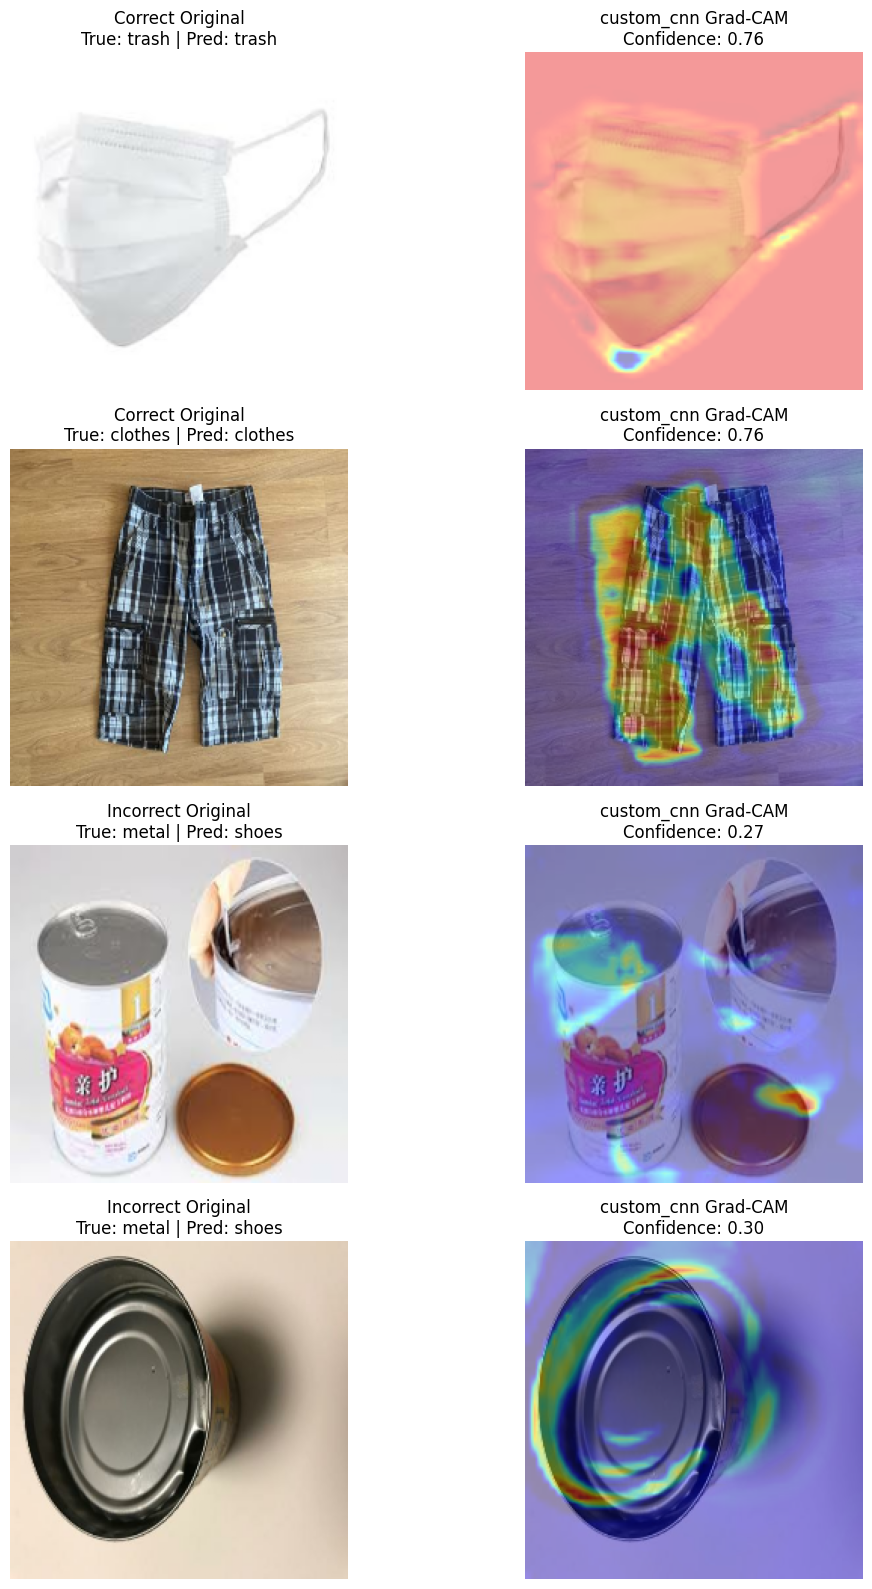

In [99]:
# ============================================================
# 24. Grad-CAM for Custom CNN
# ============================================================

def save_gradcam_examples(model, model_name, last_conv_layer_name):
    correct_examples, incorrect_examples = collect_prediction_examples(
        model=model,
        dataset=test_dataset,
        max_correct=2,
        max_incorrect=2
    )

    examples = correct_examples + incorrect_examples
    if len(examples) == 0:
        print(f"No examples found for {model_name}.")
        return

    rows = []
    plt.figure(figsize=(12, 4 * len(examples)))

    for idx, example in enumerate(examples):
        image = example["image"]
        img_array = np.expand_dims(image, axis=0)

        try:
            heatmap = make_gradcam_heatmap(
                img_array=img_array,
                model=model,
                last_conv_layer_name=last_conv_layer_name,
                pred_index=example["pred_idx"]
            )
            overlayed = overlay_heatmap_on_image(image, heatmap)
        except Exception as e:
            print(f"Grad-CAM failed for {model_name}: {e}")
            overlayed = image

        true_label = class_names[example["true_idx"]]
        pred_label = class_names[example["pred_idx"]]
        status = "Correct" if true_label == pred_label else "Incorrect"

        plt.subplot(len(examples), 2, idx * 2 + 1)
        plt.imshow(image)
        plt.title(f"{status} Original\nTrue: {true_label} | Pred: {pred_label}")
        plt.axis("off")

        plt.subplot(len(examples), 2, idx * 2 + 2)
        plt.imshow(overlayed)
        plt.title(f"{model_name} Grad-CAM\nConfidence: {example['probability']:.2f}")
        plt.axis("off")

        rows.append({
            "Model": model_name,
            "Status": status,
            "True Label": true_label,
            "Predicted Label": pred_label,
            "Confidence": example["probability"]
        })

    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f"{model_name}_gradcam_examples.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    pd.DataFrame(rows).to_csv(TABLE_PATH / f"{model_name}_gradcam_examples.csv", index=False)

custom_last_conv = "conv2d_2"
save_gradcam_examples(custom_cnn, "custom_cnn", custom_last_conv)

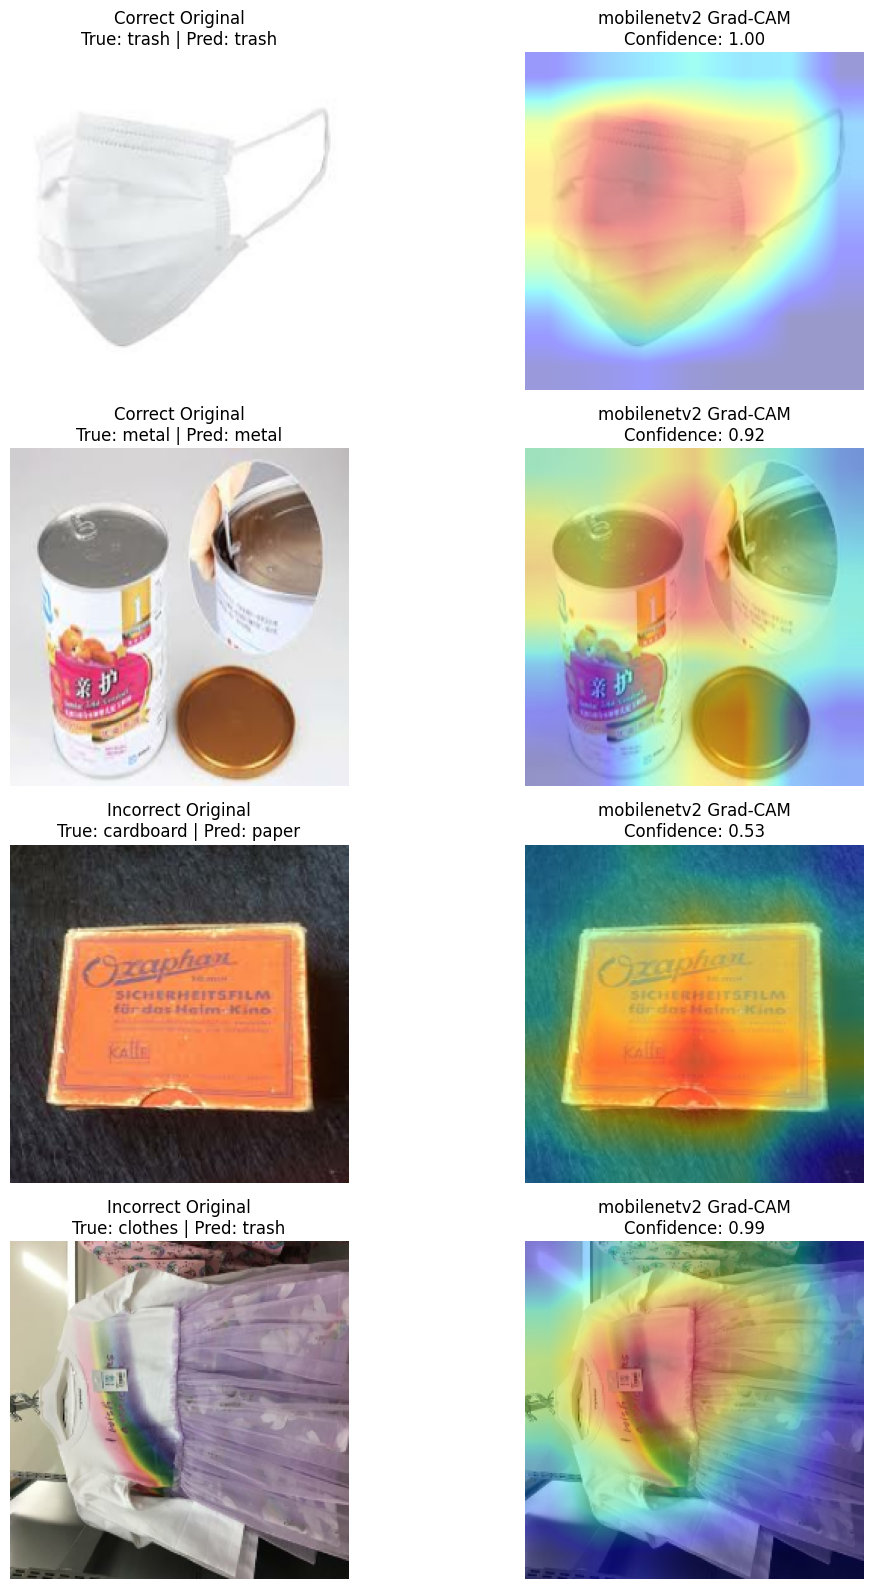

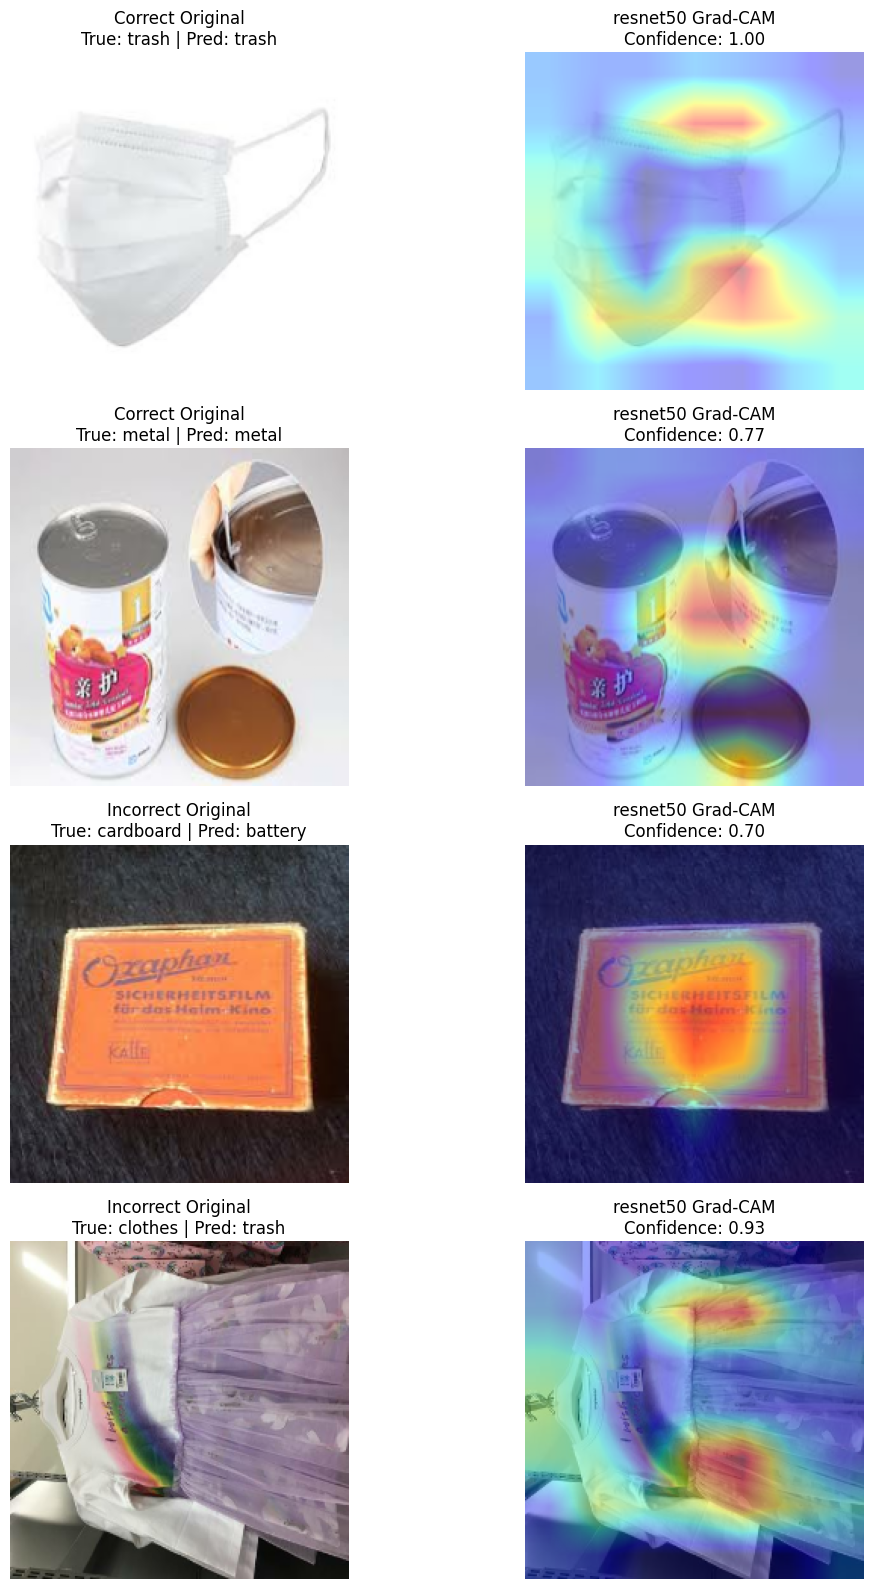

In [131]:
# ============================================================
# 25. Grad-CAM for Transfer Learning Models
# ============================================================


transfer_gradcam_layer_names = {
    "mobilenetv2": "Conv_1",
    "resnet50": "conv5_block3_out"
}

try:
    save_gradcam_examples(mobilenetv2_model, "mobilenetv2", transfer_gradcam_layer_names["mobilenetv2"])
except Exception as e:
    print("MobileNetV2 Grad-CAM skipped because of:", e)

try:
    save_gradcam_examples(resnet50_model, "resnet50", transfer_gradcam_layer_names["resnet50"])
except Exception as e:
    print("ResNet50 Grad-CAM skipped because of:", e)

Running SHAP with PartitionExplainer for maximum compatibility...


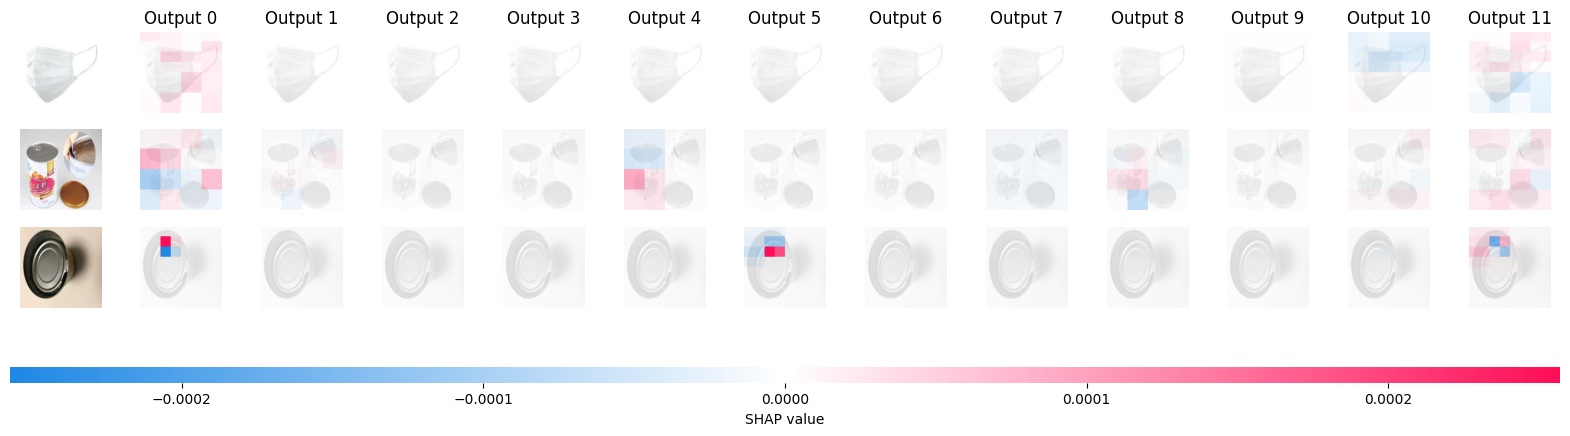

SHAP analysis completed successfully.


In [132]:
# ============================================================
# 26. SHAP
# ============================================================

try:
    import shap

    print("Running SHAP with PartitionExplainer for maximum compatibility...")

    background = next(iter(train_dataset.take(1)))[0].numpy()[:5]
    test_data = next(iter(test_dataset.take(1)))[0].numpy()[:3]

    masker = shap.maskers.Image("inpaint_telea", test_data[0].shape)
    explainer = shap.PartitionExplainer(custom_cnn, masker)
    
    shap_values = explainer(test_data, max_evals=100)

    shap.image_plot(shap_values, show=False)
    plt.savefig(FIGURE_PATH / "custom_cnn_shap_examples.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    shap_summary = pd.DataFrame([{
        "Model": "Custom CNN",
        "SHAP Status": "Completed",
        "Explained Test Images": len(test_data)
    }])
    shap_summary.to_csv(TABLE_PATH / "custom_cnn_shap_summary.csv", index=False)
    print("SHAP analysis completed successfully.")

except Exception as e:
    print(f"SHAP failed: {e}")

    pd.DataFrame([{"Model": "Custom CNN", "SHAP Status": "Skipped", "Reason": str(e)}]).to_csv(TABLE_PATH / "custom_cnn_shap_summary.csv", index=False)

In [128]:
# ============================================================
# 27. Save Final Output ZIP
# ============================================================

zip_path = "/kaggle/working/waste_classification_final_outputs.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name="/kaggle/working/waste_classification_final_outputs",
    format="zip",
    root_dir=OUTPUT_PATH
)

print("Final outputs zipped successfully.")
print("ZIP file path:", zip_path)

Final outputs zipped successfully.
ZIP file path: /kaggle/working/waste_classification_final_outputs.zip


# End of Notebook

After running all cells, download this file from Kaggle:

```text
/kaggle/working/waste_classification_final_outputs.zip
```

It contains:
- PDF figures
- CSV tables
- Saved model files
- Grad-CAM outputs
- Optional SHAP outputs if completed

In [129]:
from IPython.display import FileLink
FileLink('waste_classification_final_outputs.zip')

/kaggle/working/waste_classification_final_outputs.zip